# Federal new-hire heatmaps: grade × education by occupation

**New federal hires** by **grade group** (columns) and **education level** (rows), for any occupational series. The grid is collapsed to 5 education buckets and 4 grade groups so it reads at a glance; margins show percentages, and the **outlined** cells mark the degree→grade *could-qualify* staircase (bachelor's→GS-7, master's→GS-9, Ph.D.→GS-11), with the headline share in the box.

**Data:** OPM/EHRI *accessions* (new hires) via the public HuggingFace dataset [`impactproject/opm-ehri-data`](https://huggingface.co/datasets/impactproject/opm-ehri-data), which mirrors [data.opm.gov](https://data.opm.gov/explore-data/data/data-downloads). Parquet is streamed remotely with DuckDB — nothing is downloaded to disk. Counts are `SUM(count)`.

**One call per figure:** `accession_heatmap("<series code>")` (defaults: GS+GG, qualifying staircase outlined). Pass `pay_plans="gs"` for GS only, or `highlight_quals=False` to drop the outlines.

In [1]:
from ehri_heatmaps import accession_heatmap

SERIES = {
    "2210": "IT Management",
    "1550": "Computer Science",
    "1560": "Data Science",
    "1530": "Statistics",
}

/Users/abigailhaddad/Documents/repos/pull_usaspending/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Figure 1 — All occupations (GS + GG)

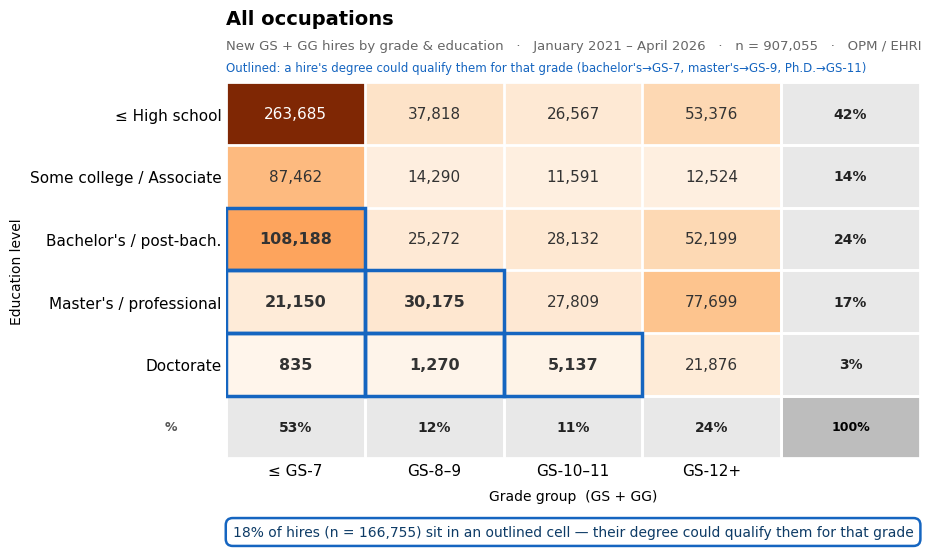

In [2]:
accession_heatmap();

### Figure 2 — 2210 (IT Management)

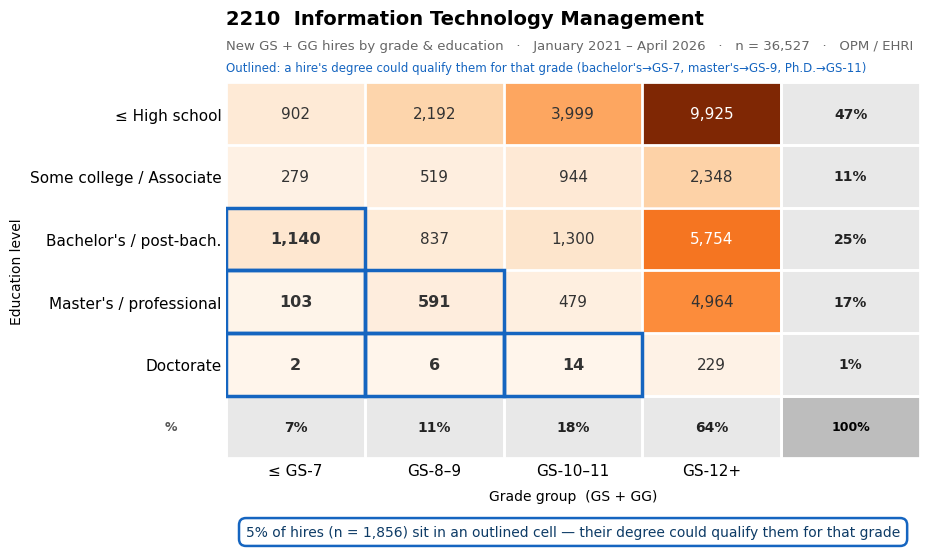

In [3]:
accession_heatmap("2210");

### Figure 3 — 1550 (Computer Science)

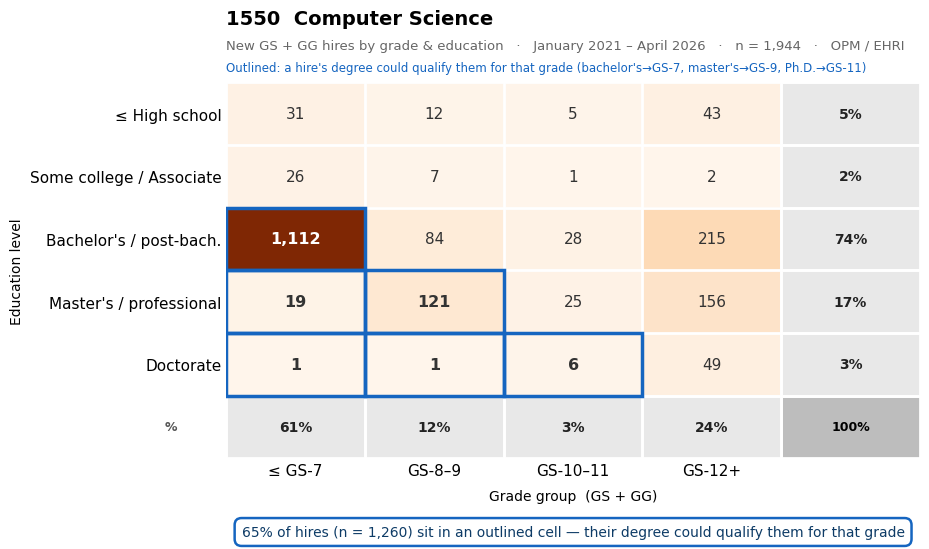

In [4]:
accession_heatmap("1550");

### Figure 4 — 1560 (Data Science)

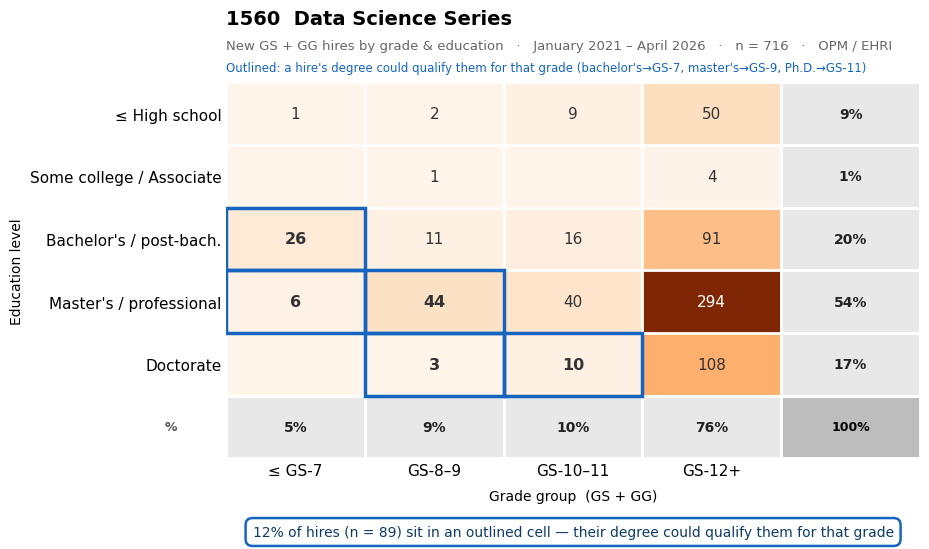

In [5]:
accession_heatmap("1560");

### Figure 5 — 1530 (Statistics)

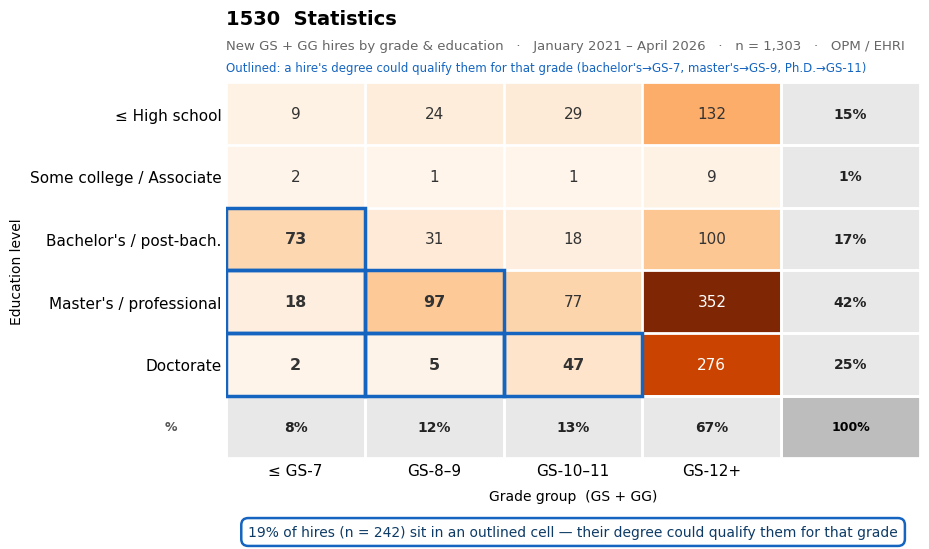

In [6]:
accession_heatmap("1530");

### Add any other series — same call, just change the code

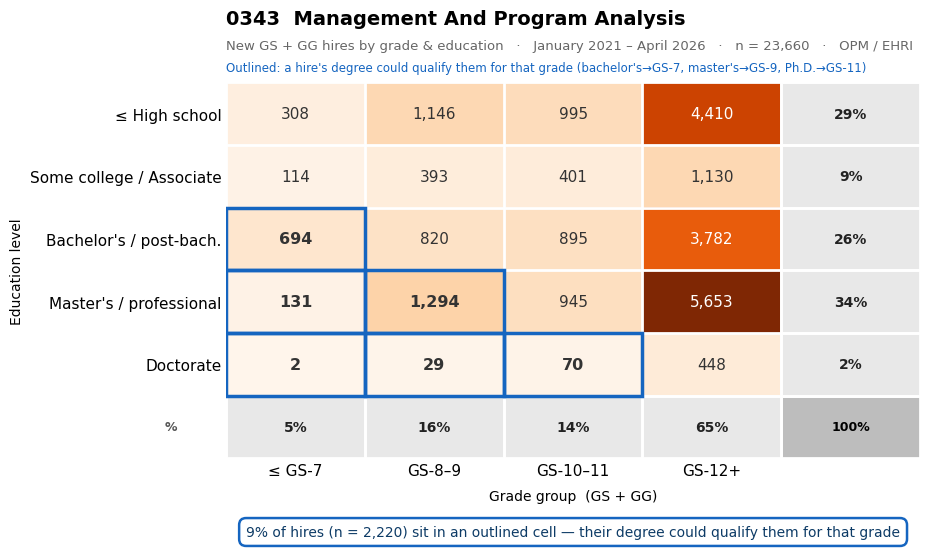

In [7]:
# e.g. 0343 Management Analysis, 0905 Attorney, 0610 Nurse ...
accession_heatmap("0343");

## Save figures to disk

wrote heatmap_all.png
wrote heatmap_2210.png


wrote heatmap_1550.png
wrote heatmap_1560.png


wrote heatmap_1530.png


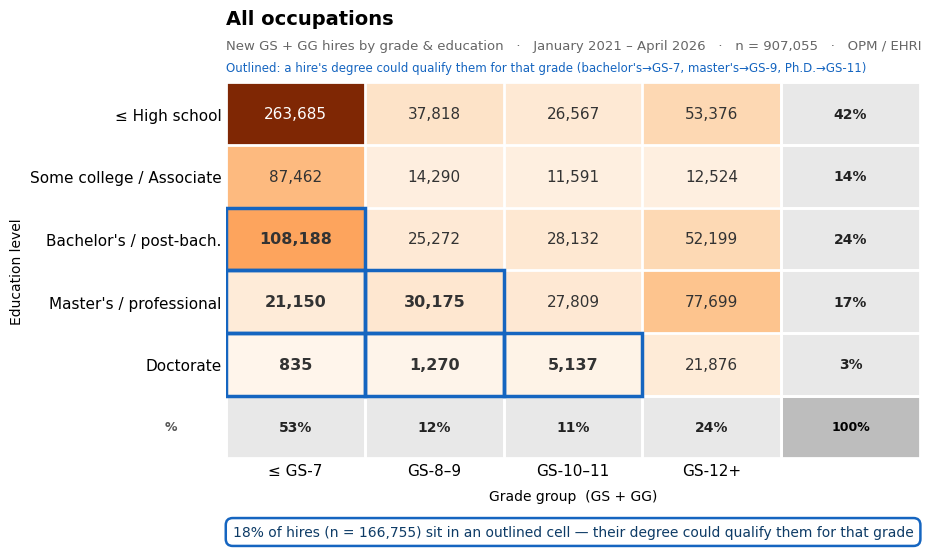

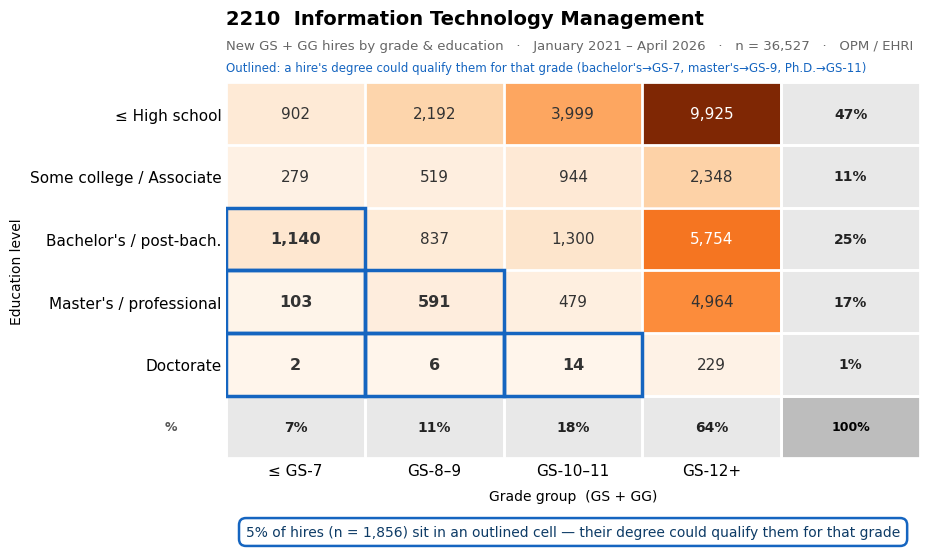

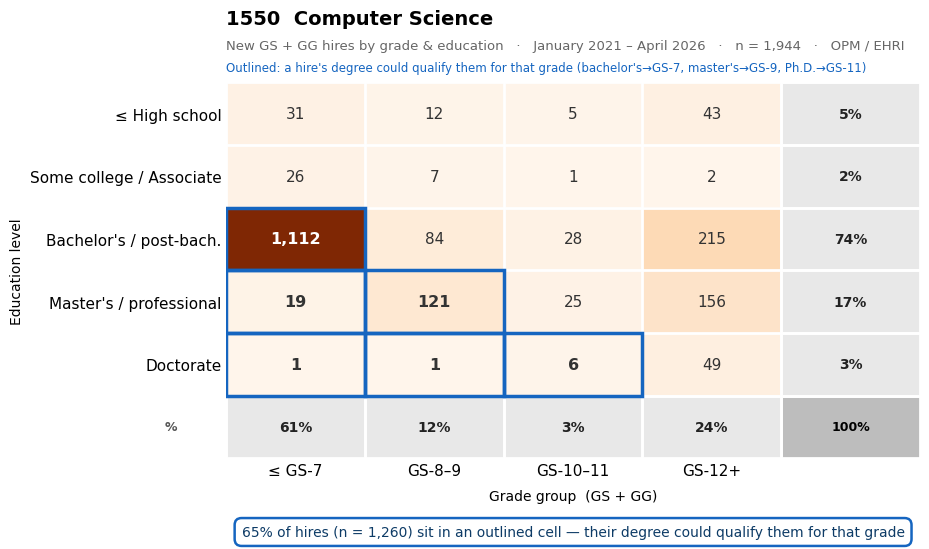

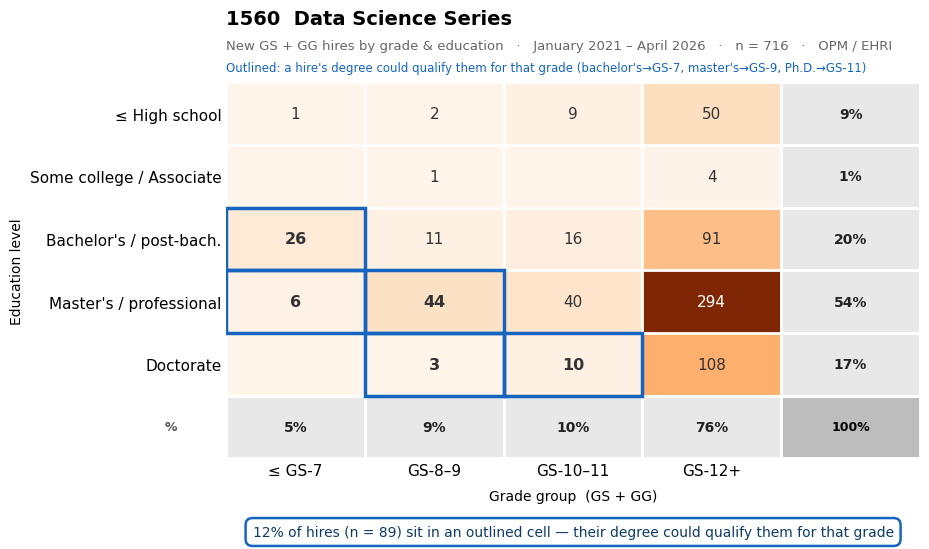

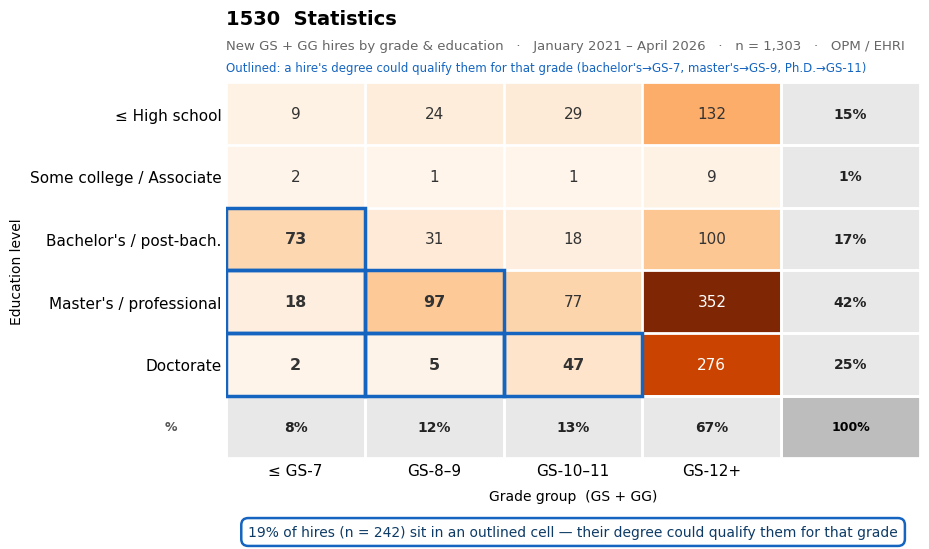

In [8]:
accession_heatmap(out="heatmap_all.png")
for code in SERIES:
    accession_heatmap(code, save=True)

## Methodology & caveats

- **Unit:** OPM/EHRI *accessions* = personnel actions that add an employee to the federal workforce (new hires, transfers in). Each parquet row is pre-aggregated; figures use `SUM(count)`.
- **Window:** accession effective month `>= 202101`; the subtitle reports the actual range (currently January 2021 – April 2026). Change `START_MONTH` in `ehri_heatmaps.py` to adjust.
- **Education buckets** collapse the raw `education_level_code` into ≤ high school · some college/associate · bachelor's/post-bach · master's/professional · doctorate. "Master's / professional" folds in first-professional and sixth-year degrees, credited at GS-9. For series with no positive degree requirement (e.g. 2210), "≤ High school" reflects the qualifying education recorded, not necessarily the employee's highest attainment.
- **Grade groups:** ≤ GS-7 · GS-8–9 · GS-10–11 · GS-12+, on the GS scale (GS + GG by default; `pay_plans="gs"` for GS only). Empty low grades fold into ≤ GS-7.
- **Qualifying-cell outlines** mark where a hire's degree could qualify them for that grade under OPM's group-coverage standard (bachelor's→GS-7, master's→GS-9, Ph.D.→GS-11), each degree also covering the lower groups. The box sums those cells as a share of all hires shown. They flag where a degree *could* be the basis of qualification; they don't prove it was, and they exclude experience-based qualification.
- **Latest months** are revised by OPM over time; re-running picks up the newest published version of each month automatically.